# Lead–Lag Analysis (clean workflow)

This notebook loads the balanced weekly panel and produces:

- Descriptive brand time-series and cross-correlations
- Event-study plots (with 95% CIs)
- Optional diagnostics (non-overlap windows, alignment shifts, week-demeaned)
- Placebo and Event−Placebo difference plots

Reusable helpers (plotting, event selection) live in `code/lead_lag_analysis.py`. The notebook focuses on orchestration and visualization.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from panel_analysis_helpers import (
    add_normalizations, event_study_value,
    xcorr_by_company, plot_xcorr,
    plot_event_ci, plot_brand_timeseries,
    NYT_POS,
    NYT_NEG,
    NYT_SENT,
    NYT_NON_NEUTRAL,
    NYT_COUNT,
    MEME_COUNT,
    MEME_Z,
    MEME_REL,

)
from panel_checks import (
    check_required_columns, summarize_missingness, continuity_by_year)


## Initialization

In [2]:
REPO_ROOT = "/Users/beszabo/bene/szakdolgozat"
DERIVED_DIR = os.path.join(REPO_ROOT, "data", "panels")
FIG_DIR = os.path.join(REPO_ROOT, "figures")

# Use balanced, calendar-complete panel for event study
PANEL_CSV = os.path.join(DERIVED_DIR, "company_weekly_panel_analysis_ready.csv")

panel = pd.read_csv(PANEL_CSV, parse_dates=['week_start'])

# Add normalizations (NaN-aware z, relative)
panel = add_normalizations(panel)

check_required_columns(
    panel,
    required=['company', 'week_start', 'NYT_mention', 'num_memes'],
    optional=['meme_engagement', 'sentiment_score', NYT_POS, NYT_NEG,
              NYT_NON_NEUTRAL]
)
print(summarize_missingness(
    panel,
    ['NYT_mention', 'num_memes', NYT_POS, NYT_NEG, NYT_NON_NEUTRAL]
))
print(continuity_by_year(panel, 'NYT_mention').head())


                   non_null_share
NYT_mention              1.000000
num_memes                1.000000
mean_pos                 0.442722
mean_neg                 0.442722
non_neutral_share        0.442722
  company  year  share_weeks_with_val
0  adidas  2022              0.000000
1  adidas  2023              0.788462
2  adidas  2024              0.075472
3  airbnb  2022              1.000000
4  airbnb  2023              0.903846


## Event study

In [ ]:
# Event study on NaN-aware z outcome, using balanced panel indexing
pos_z, neg_z = event_study_value(panel,
                                 pos_feature=NYT_POS,
                                 neg_feature=NYT_NEG,
                                 value_col=MEME_Z,
                                 window=3)


## Descriptive brand time-series 

In [ ]:
# Select a few brands (top by NYT articles)
top_companies = (
    panel.groupby('company')['NYT_mention']
            .sum()
            .sort_values(ascending=False)
            .head(10)
            .index
            .tolist()
)
for c in top_companies:
    out = os.path.join(FIG_DIR, f"ts_{c}_num_articles_vs_num_memes_z.png")
    plot_brand_timeseries(panel, c, left_col='NYT_mention', right_col='num_memes_z', smooth=4, out_path=out)
    print(f"Saved {out}")


## Event-study plots

In [ ]:
# Event-study with 95% CIs


# Event-study plots with 95% confidence intervals (NaN-aware z outcome)
plot_event_ci(pos_z, MEME_Z,
              'Event: Positive news vs normalized (z) meme volume (95% CI)',
              os.path.join(FIG_DIR, 'event_pos_num_memes_z_ci.png'))
plot_event_ci(neg_z, MEME_Z,
              'Event: Negative news vs normalized (z) meme volume (95% CI)',
              os.path.join(FIG_DIR, 'event_neg_num_memes_z_ci.png'))
print('Saved CI event-study plots.')


Saved /Users/beszabo/bene/szakdolgozat/figures/ts_facebook_num_articles_vs_num_memes_z.png
Saved /Users/beszabo/bene/szakdolgozat/figures/ts_youtube_num_articles_vs_num_memes_z.png
Saved /Users/beszabo/bene/szakdolgozat/figures/ts_netflix_num_articles_vs_num_memes_z.png
Saved /Users/beszabo/bene/szakdolgozat/figures/ts_google_num_articles_vs_num_memes_z.png
Saved /Users/beszabo/bene/szakdolgozat/figures/ts_instagram_num_articles_vs_num_memes_z.png
Saved /Users/beszabo/bene/szakdolgozat/figures/ts_apple_num_articles_vs_num_memes_z.png
Saved /Users/beszabo/bene/szakdolgozat/figures/ts_microsoft_num_articles_vs_num_memes_z.png
Saved /Users/beszabo/bene/szakdolgozat/figures/ts_amazon_num_articles_vs_num_memes_z.png
Saved /Users/beszabo/bene/szakdolgozat/figures/ts_tesla_num_articles_vs_num_memes_z.png
Saved /Users/beszabo/bene/szakdolgozat/figures/ts_spotify_num_articles_vs_num_memes_z.png
Saved CI event-study plots.


## XCorr

In [4]:
# Create L1..L4 for selected predictors (if not already present)
lag_sources = [c for c in [NYT_COUNT,NYT_SENT,NYT_POS,NYT_NEG,NYT_NON_NEUTRAL] if c in panel.columns]
panel = panel.sort_values(['company','week_start']).copy()
for c in lag_sources:
    for k in range(1, 5):
        col = f"{c}_L{k}"
        if col not in panel.columns:
            panel[col] = panel.groupby('company')[c].shift(k)

# Recompute CCF for NYT_mention specifically (vs num_memes_z)
df_ccf = xcorr_by_company(panel, 'NYT_mention', max_lag=4)
out_ccf = os.path.join(FIG_DIR, 'xcorr_NYT_mention_vs_num_memes_z.png')
plot_xcorr(df_ccf, 'Lead-Lag: NYT_mention vs num_memes_z', out_ccf)
print('Saved', out_ccf)


Saved /Users/beszabo/bene/szakdolgozat/figures/xcorr_NYT_mention_vs_num_memes_z.png


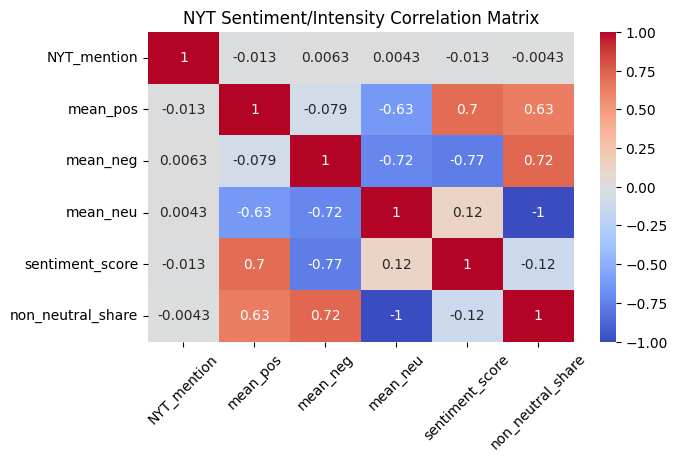

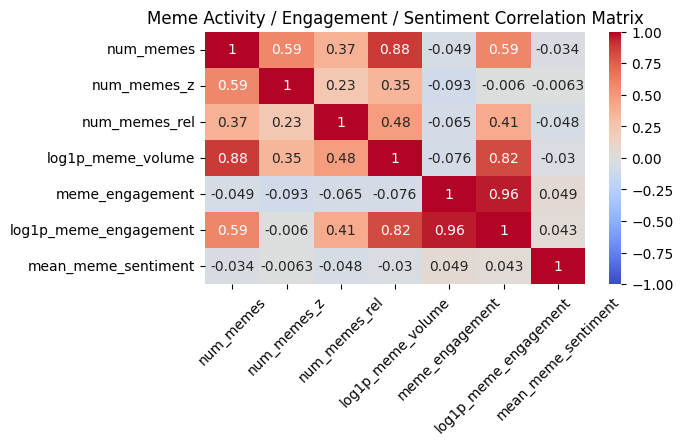

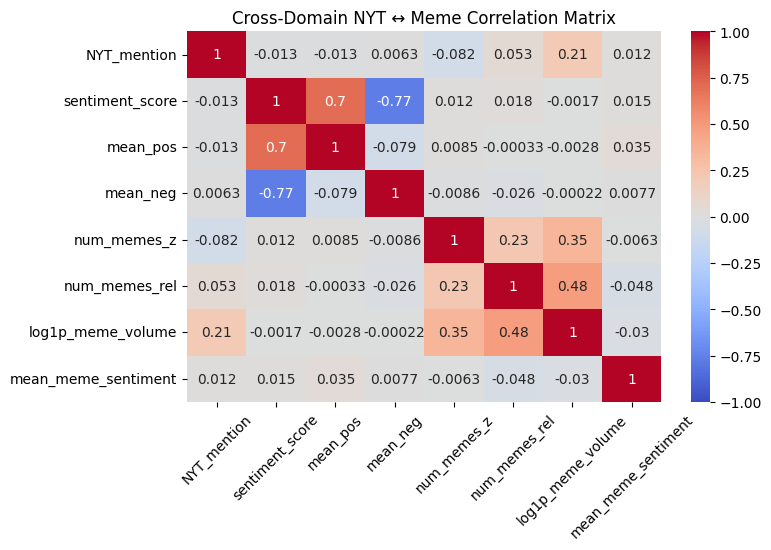

In [ ]:
# correlation matrix of NYT_COUNT, NYT_POS, NYT_NEG, NYT_SENT, NYT_NON_NEUTRAL
from panel_analysis_helpers import corrmx_nyt
from panel_analysis_helpers import corrmx_meme
from panel_analysis_helpers import corrmx_cross

nyt_meme_cross_matrix = corrmx_nyt(panel)
meme_matrix = corrmx_meme(panel)
nyt_meme_cross_matrix = corrmx_cross(panel)


# Sanity checks

In [ ]:
from panel_analysis_helpers import run_alt_outcome_event_studies
from panel_analysis_helpers import run_event_alignment_diagnostics
from panel_analysis_helpers import run_nyt_spike_event_study
from panel_analysis_helpers import (
    build_event_dict, run_placebo_event_study, run_event_placebo_diff,
    NYT_POS, NYT_NEG, MEME_Z)

run_alt_outcome_event_studies(panel, FIG_DIR)

run_event_alignment_diagnostics(panel, FIG_DIR)

run_nyt_spike_event_study(panel, FIG_DIR)

pos_events = build_event_dict(panel, NYT_POS, q=0.90, non_overlapping=True)
neg_events = build_event_dict(panel, NYT_NEG, q=0.90, non_overlapping=True)

pos_placebo, neg_placebo = run_placebo_event_study(panel, pos_events, neg_events,
                                                   FIG_DIR)

run_event_placebo_diff(pos_z, pos_placebo, MEME_Z,
                       'Event – Placebo (pos): z meme volume',
                       os.path.join(FIG_DIR, 'results/event_diff/event_pos_num_memes_z_diff_ci.png'))
run_event_placebo_diff(neg_z, neg_placebo, MEME_Z,
                       'Event – Placebo (neg): z meme volume',
                       os.path.join(FIG_DIR, 'results/event_diff/event_neg_num_memes_z_diff_ci.png'))

Saved alternative outcome CI event-study plots.
Events kept (pos/neg): 350 341
shift_m1 tau0 mean= 0.014496512535277855
shift_p1 tau0 mean= -0.007778270994128533
Saved no-overlap, shift tests, and demeaned-week diagnostics.
Saved NYT mention spike event-study plots.
Placebo pos tau0 mean = -0.03497522360800943
Placebo neg tau0 mean = -0.04515649992667618
